🎯 Target Project Root: /Users/etiennerv/Jts/EUA Forecasting/EUA-forecasting
📁 Checking for 'src' folder existence: True
✅ Custom evaluation module imported successfully!
Calculating final evaluation statistics...

=== XGBoost Baseline ===
  RMSE              : 10.38 EUR/tCO2
  MAE               : 8.99 EUR/tCO2
  MAPE              : 11.93%
  Directional Acc.  : 59.8%
🎉 PROJECT COMPLETE! Saved final evaluation plot to: /Users/etiennerv/Jts/EUA Forecasting/EUA-forecasting/figures/oos_forecast.png


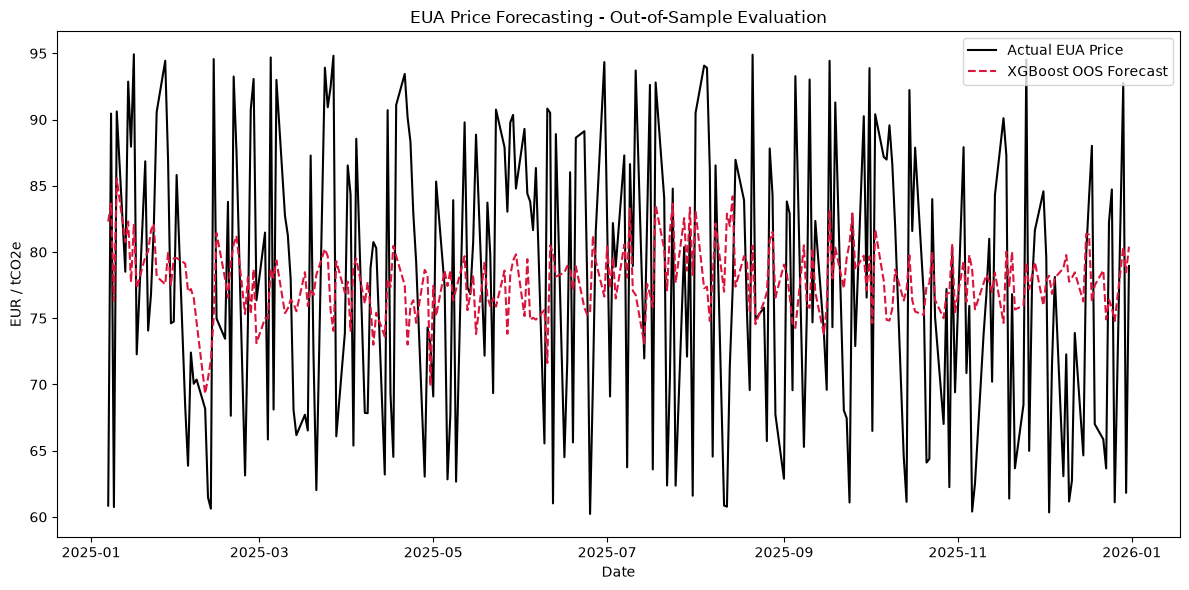

In [4]:
# =========================================================
# STEP 1: BULLETPROOF MODULE PATH INJECTION
# =========================================================
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Let's inspect your current folder path
current_dir = os.getcwd()

# Search upward for where the actual 'src' directory lives
if os.path.exists(os.path.join(current_dir, "src")):
    PROJECT_ROOT = current_dir
elif os.path.exists(os.path.join(current_dir, "..", "src")):
    PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, ".."))
else:
    # Hardcoded safety backup based on your machine's directory error trail
    PROJECT_ROOT = "/Users/etiennerv/Jts/EUA Forecasting/EUA-forecasting"

# Force inject this absolute path to the very front of Python's search list
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"🎯 Target Project Root: {PROJECT_ROOT}")
print(f"📁 Checking for 'src' folder existence: {os.path.exists(os.path.join(PROJECT_ROOT, 'src'))}")

# =========================================================
# STEP 2: IMPORT CUSTOM MODULE AND LOAD DATA
# =========================================================
from src.evaluate import evaluate_forecast

print("✅ Custom evaluation module imported successfully!")

xgb_preds_path = os.path.join(PROCESSED_DIR, "xgb_preds.csv")
xgb_results = pd.read_csv(xgb_preds_path, index_col=0, parse_dates=True)

# =========================================================
# STEP 3: RUN EVALUATION & SAVE FINAL GRAPH
# =========================================================
print("Calculating final evaluation statistics...")
metrics = evaluate_forecast(xgb_results["actual"], xgb_results["xgb_pred"], "XGBoost Baseline")

plt.figure(figsize=(12, 6))
plt.plot(xgb_results.index, xgb_results["actual"], label="Actual EUA Price", color="black", lw=1.5)
plt.plot(xgb_results.index, xgb_results["xgb_pred"], label="XGBoost OOS Forecast", color="crimson", linestyle="--", lw=1.5)
plt.title("EUA Price Forecasting - Out-of-Sample Evaluation")
plt.xlabel("Date")
plt.ylabel("EUR / tCO2e")
plt.legend()
plt.tight_layout()

final_plot_path = os.path.join(FIGURES_DIR, "oos_forecast.png")
plt.savefig(final_plot_path, dpi=150)
print(f"🎉 PROJECT COMPLETE! Saved final evaluation plot to: {final_plot_path}")
plt.show()